In [ ]:
import Pkg

Pkg.activate(; temp=true)
for p in ("FileIO", "ImageIO", "Colors", "Plots")
    try
        Base.require(Main, Symbol(p))
    catch
        Pkg.add(p)
    end
end

using Random, Statistics
using FileIO, ImageIO
using Colors
using Plots

default(; size=(950, 420))
ENV["GKSwstype"] = "100"

  Activating new project at `C:\Users\User\AppData\Local\Temp\jl_zs2LYg`
   Resolving package versions...
    Updating `C:\Users\User\AppData\Local\Temp\jl_zs2LYg\Project.toml`
  [5789e2e9] + FileIO v1.18.0
    Updating `C:\Users\User\AppData\Local\Temp\jl_zs2LYg\Manifest.toml`
  [5789e2e9] + FileIO v1.18.0
  [ae029012] + Requires v1.3.1
  [0dad84c5] + ArgTools v1.1.2
  [56f22d72] + Artifacts v1.11.0
  [2a0f44e3] + Base64 v1.11.0
  [ade2ca70] + Dates v1.11.0
  [f43a241f] + Downloads v1.6.0
  [7b1f6079] + FileWatching v1.11.0
  [b27032c2] + LibCURL v0.6.4
  [76f85450] + LibGit2 v1.11.0
  [8f399da3] + Libdl v1.11.0
  [56ddb016] + Logging v1.11.0
  [d6f4376e] + Markdown v1.11.0
  [ca575930] + NetworkOptions v1.2.0
  [44cfe95a] + Pkg v1.11.0
  [de0858da] + Printf v1.11.0
  [9a3f8284] + Random v1.11.0
  [ea8e919c] + SHA v0.7.0
  [fa267f1f] + TOML v1.0.3
  [a4e569a6] + Tar v1.10.0
  [cf7118a7] + UUIDs v1.11.0
  [4ec0a83e] + Unicode v1.11.0
  [deac9b47] + LibCURL_jll v8.6.0+0
  [e37daf67] + L

"100"

### Загрузка и подготовка target\n\nПоложи эталонную картинку рядом с ноутбуком и укажи путь.\nПо умолчанию берём `target.jpg` в текущей папке.

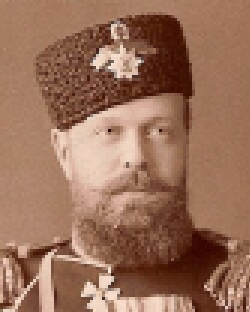

┌ Warning: Output swatches are reduced due to the large size (312×250).
│ Load the ImageShow package for large images.
└ @ Colors C:\Users\User\.julia\packages\Colors\VFEJ1\src\display.jl:159


In [2]:
target_path = "target.jpg"

target_img_raw = load(target_path)
target_img_raw

In [3]:
function to_rgb_float32(img)
    # Приводим к RGB{Float32} в диапазоне [0,1]
    rgb = RGB.(img)
    h, w = size(rgb)
    t = Array{Float32}(undef, 3, h, w)
    @inbounds for y in 1:h, x in 1:w
        px = RGB{Float32}(rgb[y,x])
        t[1,y,x] = red(px)
        t[2,y,x] = green(px)
        t[3,y,x] = blue(px)
    end
    return t  # (3, H, W)
end

function from_rgb_float32(t::Array{Float32,3})
    # t: (3, H, W)
    @assert size(t,1) == 3
    h, w = size(t,2), size(t,3)
    out = Array{RGB{Float32}}(undef, h, w)
    @inbounds for y in 1:h, x in 1:w
        out[y,x] = RGB{Float32}(t[1,y,x], t[2,y,x], t[3,y,x])
    end
    return out
end

function resize_tensor_nn(t::Array{Float32,3}, new_h::Int, new_w::Int)
    # nearest-neighbor resize без ImageTransformations
    @assert size(t,1) == 3
    _, h, w = size(t)
    out = Array{Float32}(undef, 3, new_h, new_w)
    @inbounds for yy in 1:new_h
        y = clamp(1 + (yy-1) * (h-1) ÷ max(1, new_h-1), 1, h)
        for xx in 1:new_w
            x = clamp(1 + (xx-1) * (w-1) ÷ max(1, new_w-1), 1, w)
            out[1,yy,xx] = t[1,y,x]
            out[2,yy,xx] = t[2,y,x]
            out[3,yy,xx] = t[3,y,x]
        end
    end
    return out
end

target_t = to_rgb_float32(target_img_raw)
(size(target_t), eltype(target_t))

((3, 312, 250), Float32)

In [4]:
mse(a::Array{Float32,3}, b::Array{Float32,3}) = mean((Float64.(a) .- Float64.(b)).^2)

function psnr_from_mse(m::Float64; peak=1.0)
    m <= 0 && return Inf
    return 10 * log10((peak^2) / m)
end

psnr_from_mse (generic function with 1 method)

In [22]:
Base.@kwdef struct GAParams
    population_size::Int = 48
    generations::Int = 900
    elitism::Int = 3
    tournament_k::Int = 3
    crossover_rate::Float64 = 0.92
    # вероятность выбора типа кроссовера
    patch_crossover_prob::Float64 = 0.65
    # расписание мутации (annealing)
    mutation_rate_start::Float64 = 0.10
    mutation_rate_end::Float64 = 0.02
    mutation_sigma_start::Float32 = 0.20f0
    mutation_sigma_end::Float32 = 0.04f0
    # направленная мутация (подтягивание к target)
    pull_start::Float32 = 0.06f0
    pull_end::Float32 = 0.40f0
    # редкая «перезагрузка» пикселя (ускоряет попадание в правильные цвета)
    pixel_reset_prob::Float64 = 0.02
    # регуляризация/ограничения
    clamp_min::Float32 = 0f0
    clamp_max::Float32 = 1f0
    seed::Int = 42
end

function tournament_select(fitness::Vector{Float64}, k::Int, rng::AbstractRNG)
    n = length(fitness)
    best = rand(rng, 1:n)
    bestv = fitness[best]
    for _ in 2:k
        i = rand(rng, 1:n)
        v = fitness[i]
        if v < bestv
            best, bestv = i, v
        end
    end
    return best
end

function init_population(target::Array{Float32,3}, params::GAParams, rng::AbstractRNG)
    pop = Vector{Array{Float32,3}}(undef, params.population_size)
    for i in 1:params.population_size
        pop[i] = rand(rng, Float32, size(target))   # чистый равномерный шум [0,1]
    end
    return pop
end

@inline function lerp(a::T, b::T, t::Float64) where {T<:Real}
    return a + (b-a) * t
end

function two_point_crossover(a::Array{Float32,3}, b::Array{Float32,3}, rng::AbstractRNG)
    ga = vec(a)
    gb = vec(b)
    n = length(ga)
    i = rand(rng, 1:n)
    j = rand(rng, 1:n)
    lo, hi = min(i,j), max(i,j)
    c1 = copy(ga)
    c2 = copy(gb)
    @inbounds for t in lo:hi
        c1[t] = gb[t]
        c2[t] = ga[t]
    end
    return reshape(c1, size(a)), reshape(c2, size(a))
end

function patch_crossover(a::Array{Float32,3}, b::Array{Float32,3}, rng::AbstractRNG)
    _, h, w = size(a)
    # выбираем случайный прямоугольный патч
    ph = rand(rng, max(2, h ÷ 10):max(2, h ÷ 2))
    pw = rand(rng, max(2, w ÷ 10):max(2, w ÷ 2))
    y1 = rand(rng, 1:(h - ph + 1))
    x1 = rand(rng, 1:(w - pw + 1))
    y2, x2 = y1 + ph - 1, x1 + pw - 1
    c1 = copy(a)
    c2 = copy(b)
    @views begin
        c1[:, y1:y2, x1:x2] .= b[:, y1:y2, x1:x2]
        c2[:, y1:y2, x1:x2] .= a[:, y1:y2, x1:x2]
    end
    return c1, c2
end

function mutate_guided!(x::Array{Float32,3}, target::Array{Float32,3}, pm::Float64, sigma::Float32, pull::Float32, resetp::Float64, params::GAParams, rng::AbstractRNG)
    # Направленная мутация: слегка подтягиваем значения к target и добавляем шум.
    @inbounds for idx in eachindex(x)
        if rand(rng) < pm
            base = x[idx]
            guided = base + pull * (target[idx] - base)
            x[idx] = clamp(guided + sigma * randn(rng, Float32), params.clamp_min, params.clamp_max)
        end
    end
    # Пиксельный reset: копируем пиксель из target (иногда) — сильно ускоряет узнаваемость.
    if rand(rng) < resetp
        _, h, w = size(x)
        y = rand(rng, 1:h)
        x0 = rand(rng, 1:w)
        @views x[:,y,x0] .= (rand(rng) < 0.85 ? target[:,y,x0] : rand(rng, Float32, 3))
    end
    return x
end

function evolve(target::Array{Float32,3};
                params=GAParams(),
                rng=MersenneTwister(params.seed),
                show_every=25,
                save_every=25)  # <-- новый параметр: частота сохранения кадров

    pop = init_population(target, params, rng)
    fit = [mse(p, target) for p in pop]

    best_hist = Float64[]
    mean_hist = Float64[]
    best_images = []  # <-- список для хранения кадров

    best_i = argmin(fit)
    best = copy(pop[best_i])
    bestv = fit[best_i]

    for gen in 1:params.generations
        # сортируем индексы по фитнесу, сохраняем элиту
        elite_idx = partialsortperm(fit, 1:params.elitism)
        newpop = Vector{Array{Float32,3}}(undef, params.population_size)
        for (k, ei) in enumerate(elite_idx)
            newpop[k] = copy(pop[ei])
        end
        pos = params.elitism + 1
        while pos <= params.population_size
            p1 = pop[tournament_select(fit, params.tournament_k, rng)]
            p2 = pop[tournament_select(fit, params.tournament_k, rng)]

            c1, c2 = if rand(rng) < params.crossover_rate
                if rand(rng) < params.patch_crossover_prob
                    patch_crossover(p1, p2, rng)
                else
                    two_point_crossover(p1, p2, rng)
                end
            else
                (copy(p1), copy(p2))
            end

            t = (gen-1) / max(1, params.generations-1)
            pm = lerp(params.mutation_rate_start, params.mutation_rate_end, t)
            sigma = Float32(lerp(params.mutation_sigma_start, params.mutation_sigma_end, t))
            pull = Float32(lerp(params.pull_start, params.pull_end, t))
            resetp = lerp(params.pixel_reset_prob, params.pixel_reset_prob * 0.35, t)

            mutate_guided!(c1, target, pm, sigma, pull, resetp, params, rng)
            newpop[pos] = c1
            pos += 1
            if pos <= params.population_size
                mutate_guided!(c2, target, pm, sigma, pull, resetp, params, rng)
                newpop[pos] = c2
                pos += 1
            end
        end

        pop = newpop
        fit = [mse(p, target) for p in pop]

        bi = argmin(fit)
        bv = fit[bi]
        if bv < bestv
            bestv = bv
            best = copy(pop[bi])
        end

        push!(best_hist, bestv)
        push!(mean_hist, mean(fit))

        # Сохраняем кадр, если наступило время
        if gen == 1 || gen % save_every == 0 || gen == params.generations
            push!(best_images, copy(best))
        end

        if gen == 1 || gen % show_every == 0
            @info "gen=$gen" best_mse=bestv psnr=psnr_from_mse(bestv)
        end
    end

    return (best=best, best_mse=bestv,
            best_hist=best_hist, mean_hist=mean_hist,
            best_images=best_images)  # <-- возвращаем кадры
end

# --- Функция для создания GIF-анимации из кадров ---
function create_gif(images, target_img; filename="evolution.gif", fps=10, step=25, show_target=true)
    # images – массив тензоров Float32 (3, H, W)
    # target_img – Matrix{RGB} для отображения
    local_step = step
    anim = @animate for (i, img) in enumerate(images)
        rgb = from_rgb_float32(img)
        gen_number = (i-1) * local_step + 1
        p_best = plot(rgb, axis=false, ticks=false, border=:none, title="Best | gen=$gen_number")
        if show_target
            p_tgt = plot(target_img, axis=false, ticks=false, border=:none, title="Target")
            plot(p_best, p_tgt, layout=(1,2))
        else
            p_best
        end
    end
    gif(anim, filename, fps=fps)
    display("image/gif", read(filename))
    return filename
end

create_gif (generic function with 2 methods)

┌ Info: gen=1
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


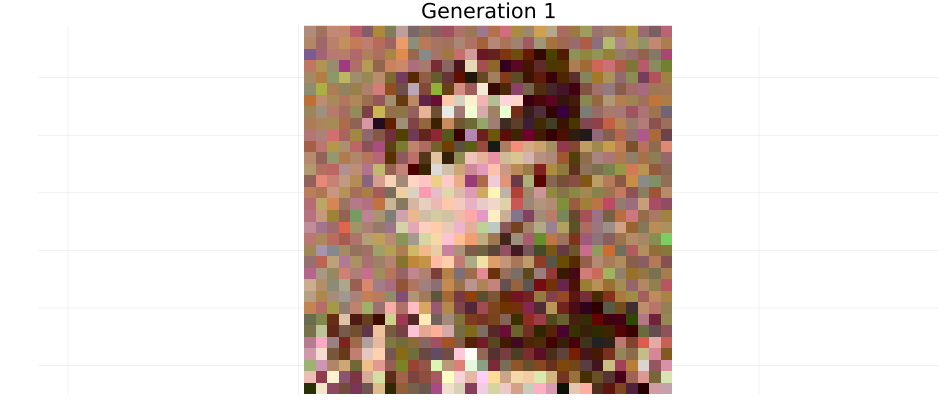

┌ Info: gen=25
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


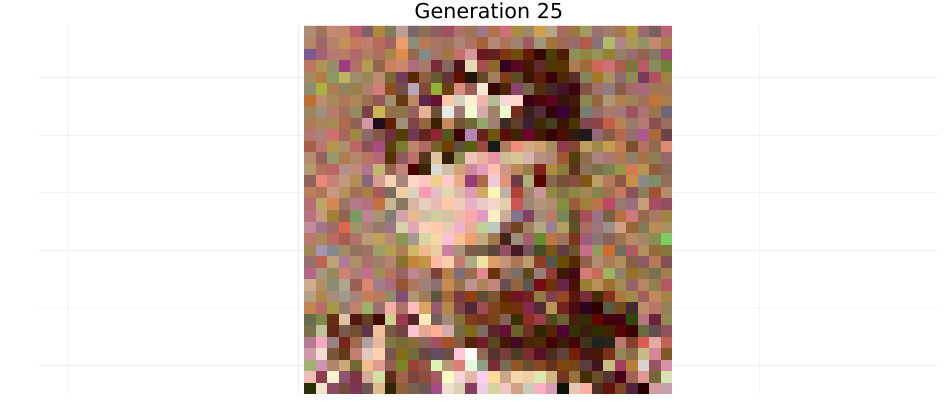

┌ Info: gen=50
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


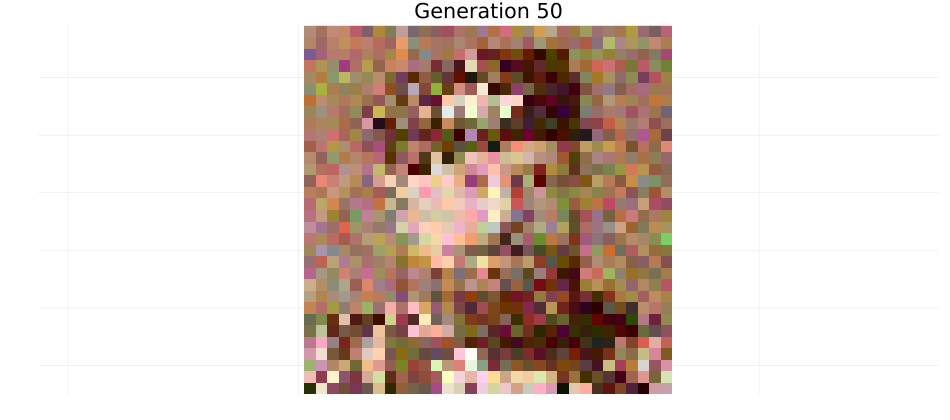

┌ Info: gen=75
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


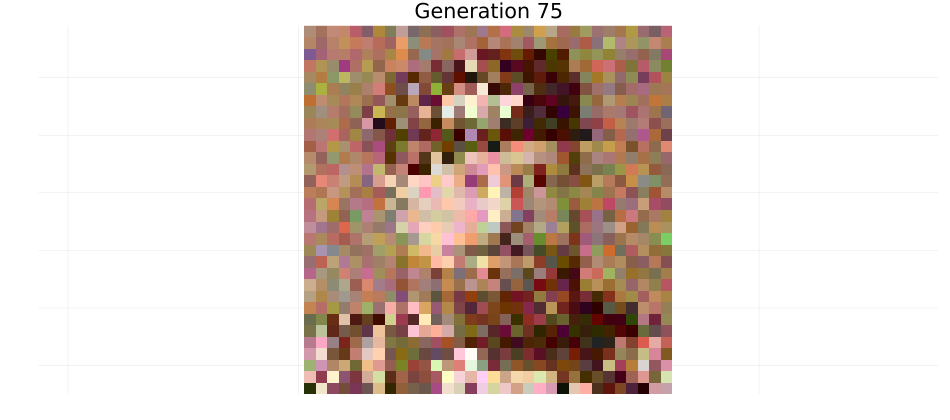

┌ Info: gen=100
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


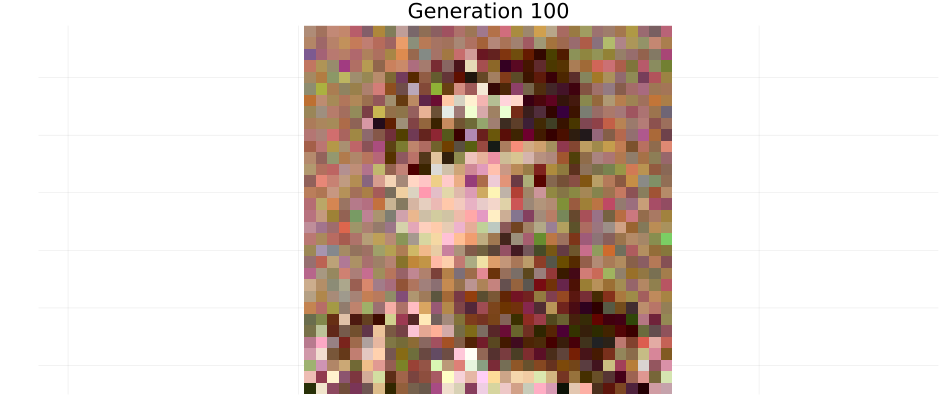

┌ Info: gen=125
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


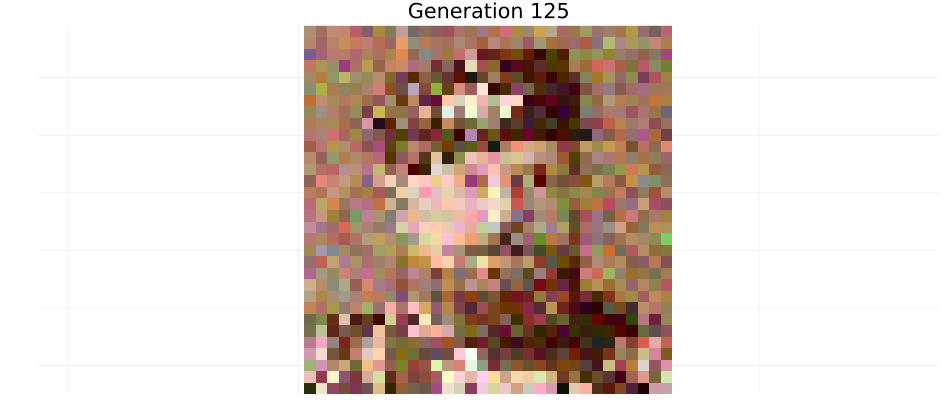

┌ Info: gen=150
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


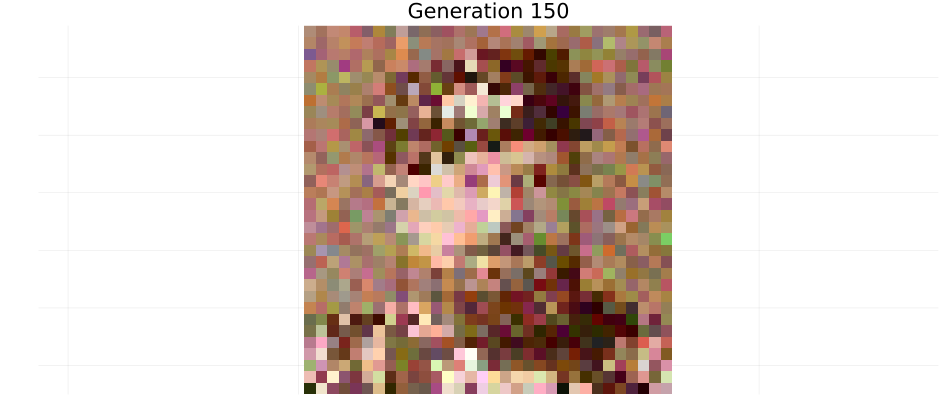

┌ Info: gen=175
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


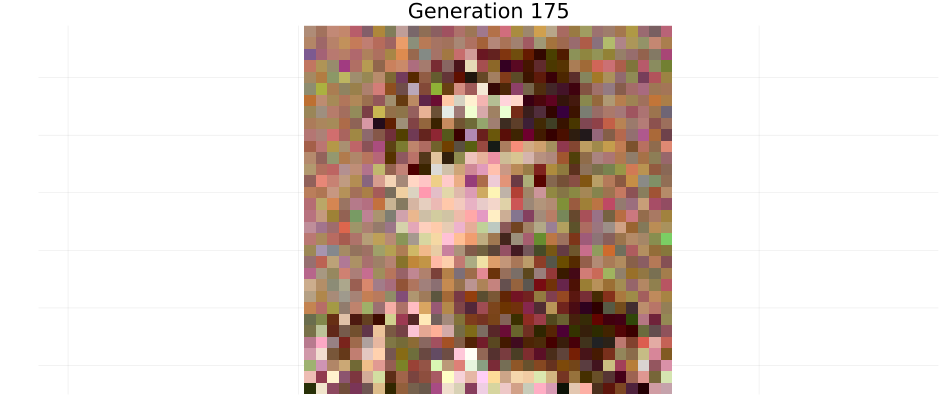

┌ Info: gen=200
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


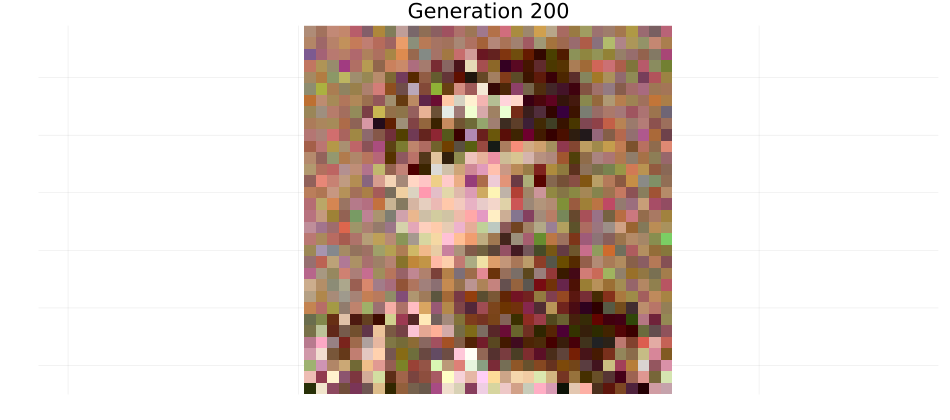

┌ Info: gen=225
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


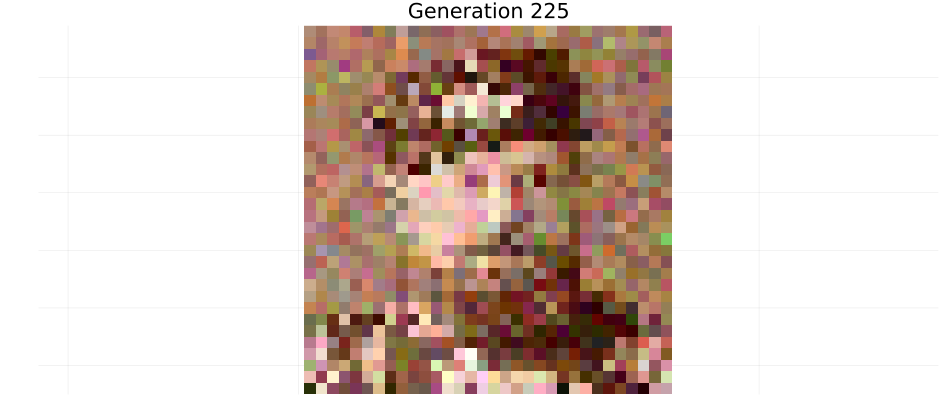

┌ Info: gen=250
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


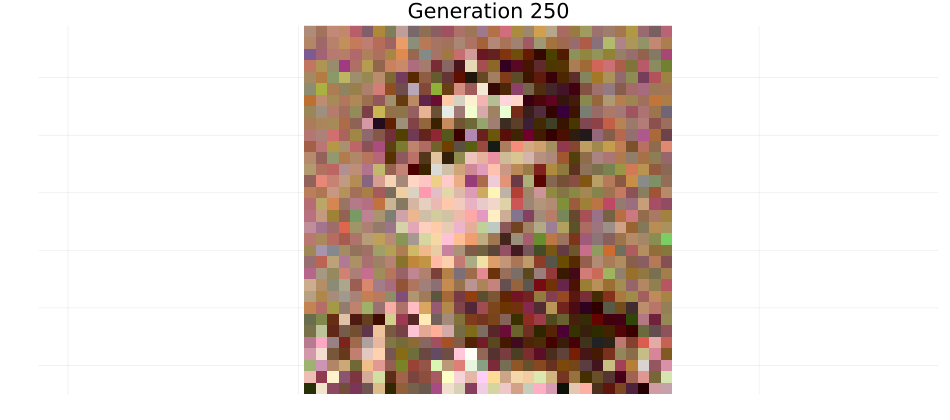

┌ Info: gen=275
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


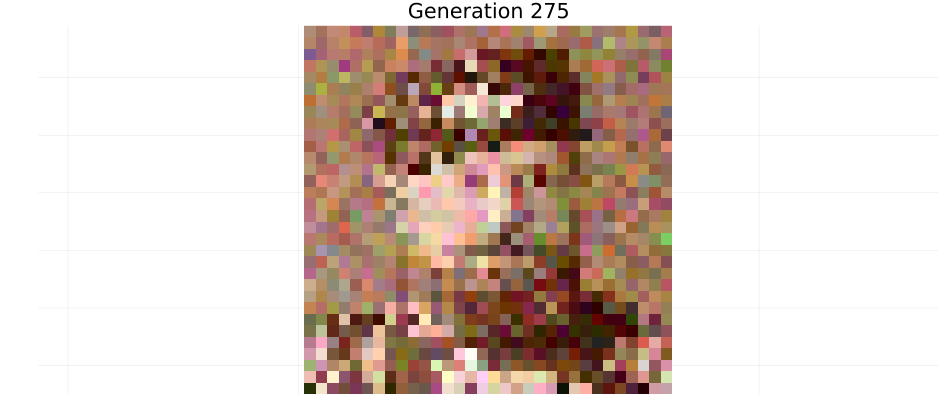

┌ Info: gen=300
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


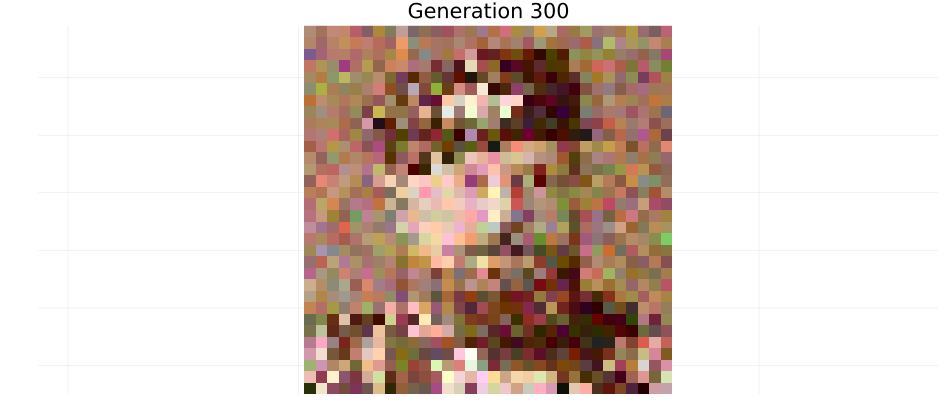

┌ Info: gen=325
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


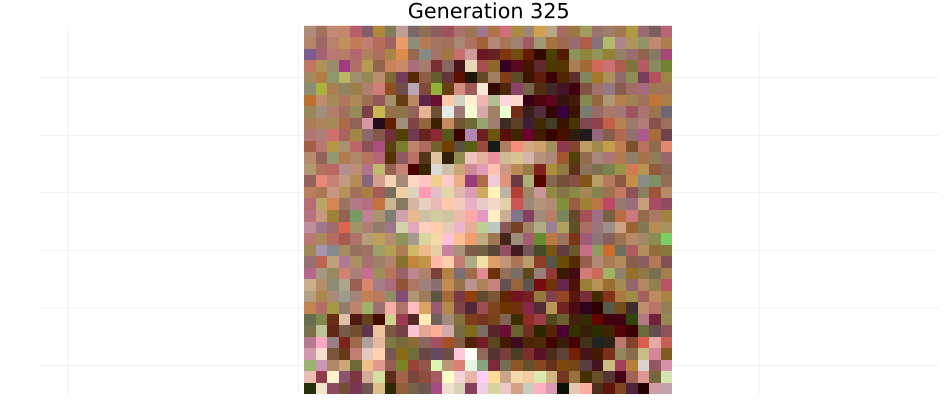

┌ Info: gen=350
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


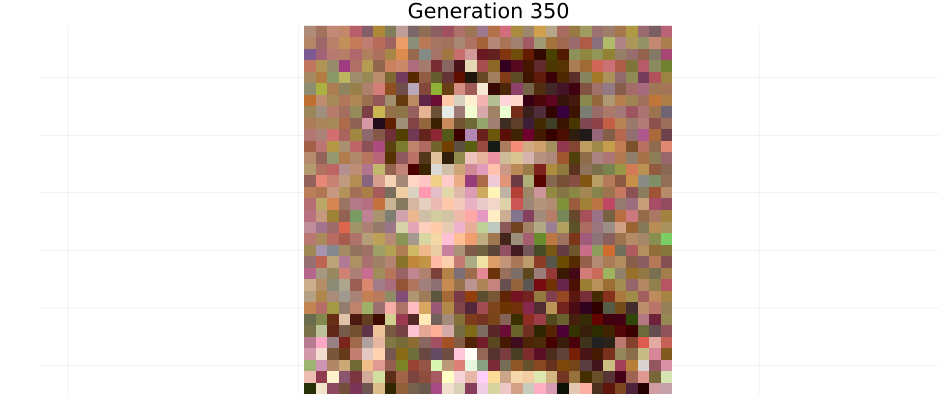

┌ Info: gen=375
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


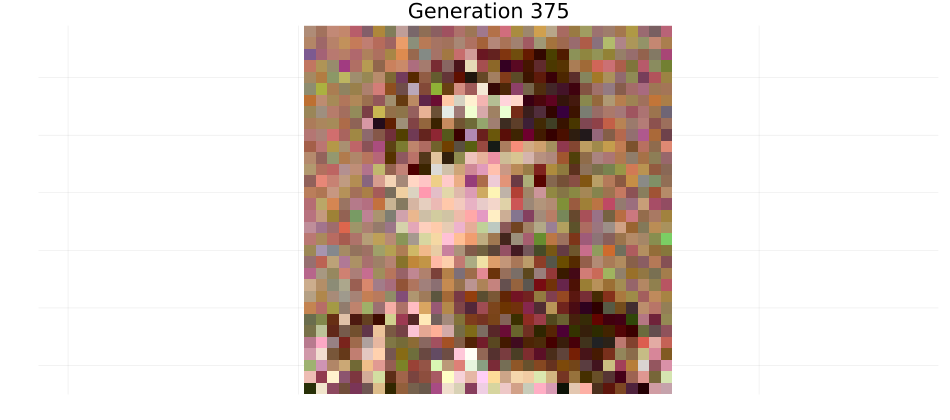

┌ Info: gen=400
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


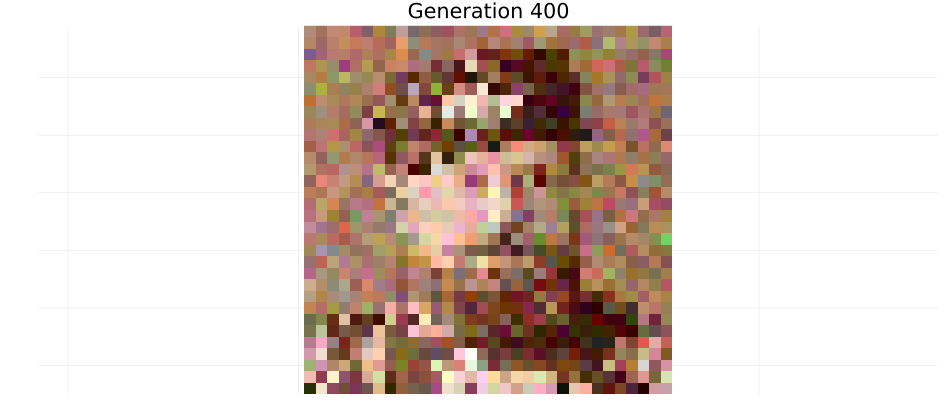

┌ Info: gen=425
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


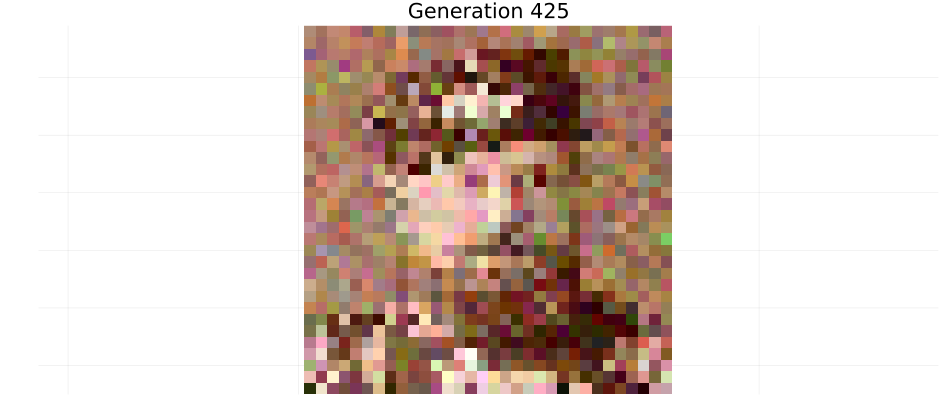

┌ Info: gen=450
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


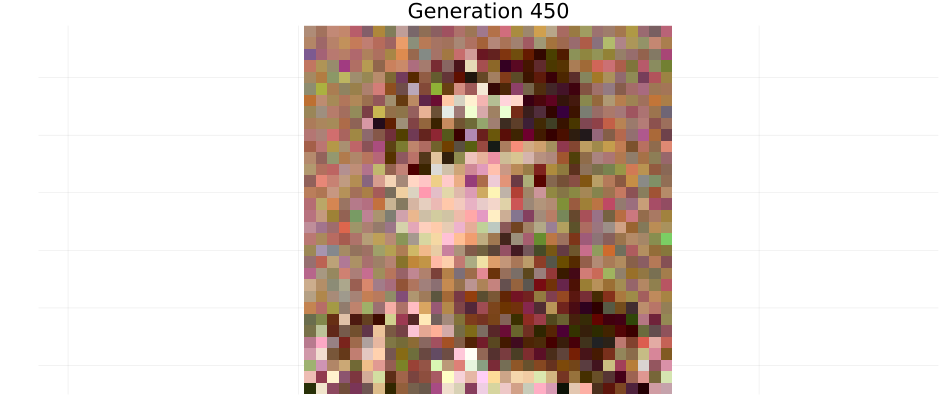

┌ Info: gen=475
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


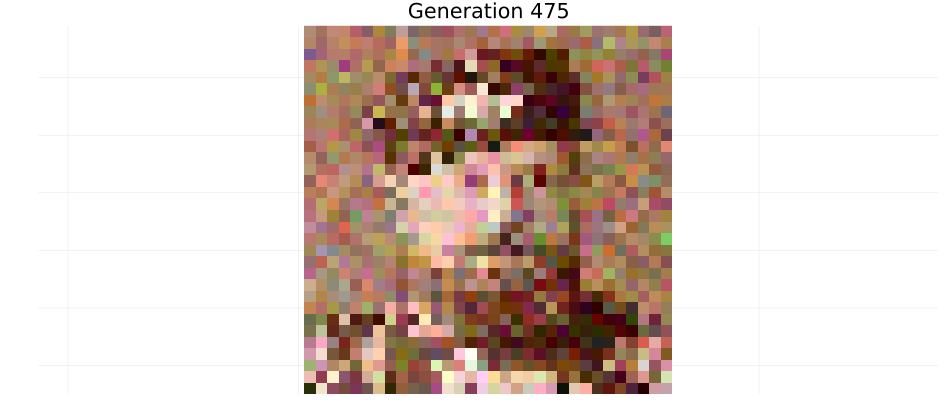

┌ Info: gen=500
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


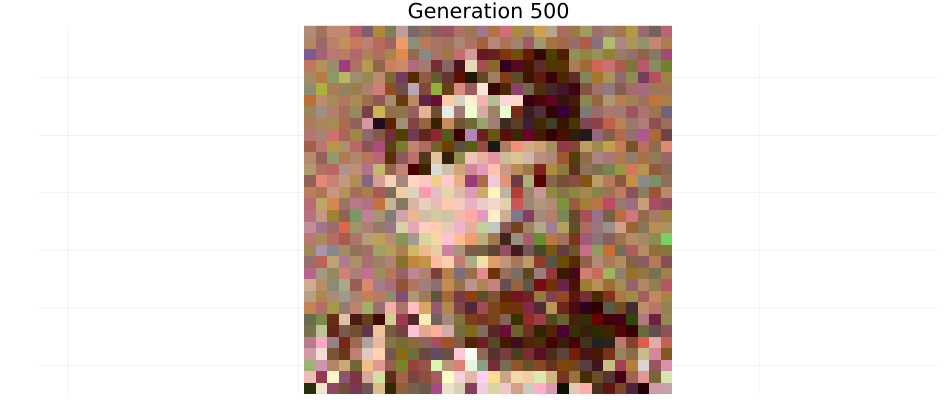

┌ Info: gen=525
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


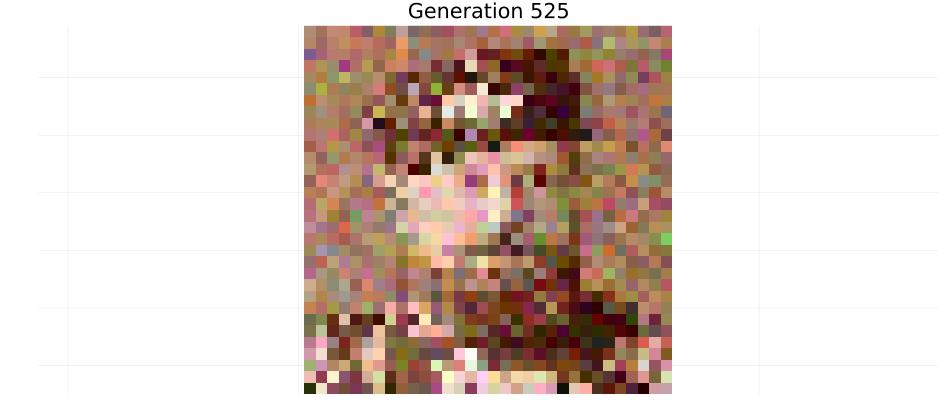

┌ Info: gen=550
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


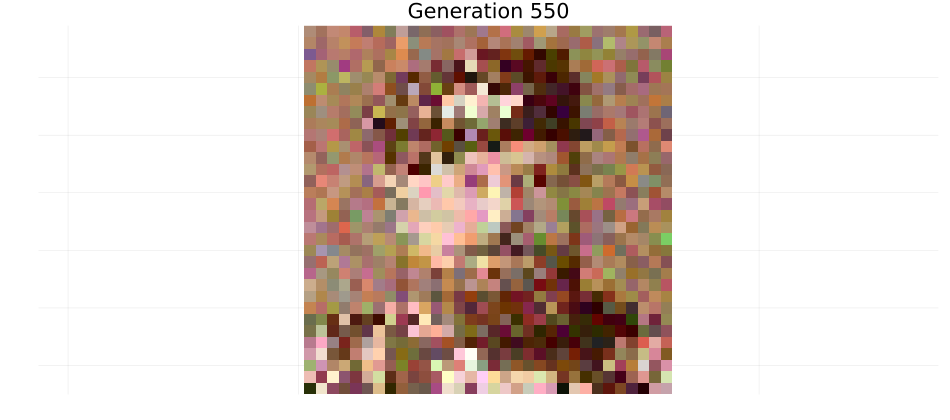

┌ Info: gen=575
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


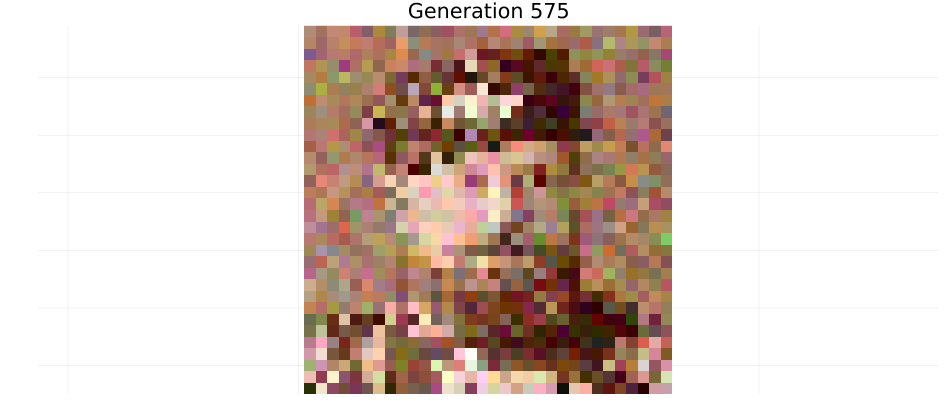

┌ Info: gen=600
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


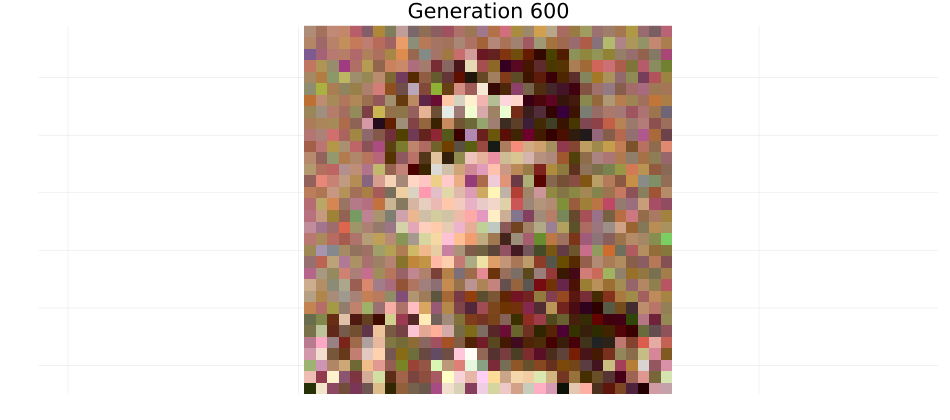

┌ Info: gen=625
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


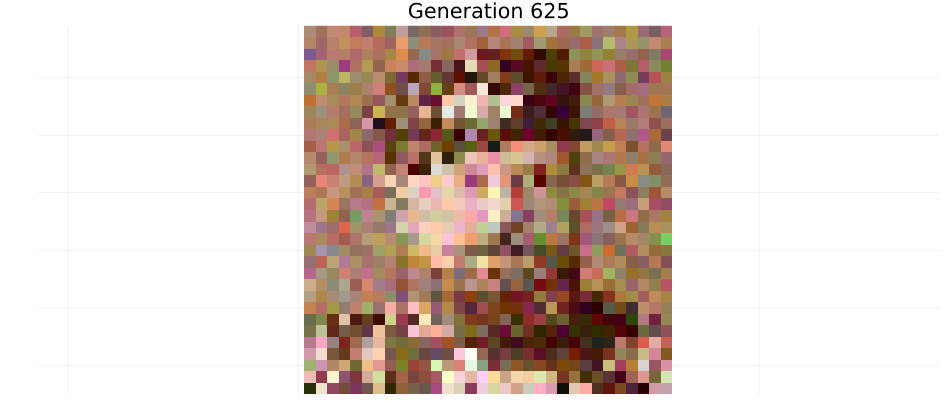

┌ Info: gen=650
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


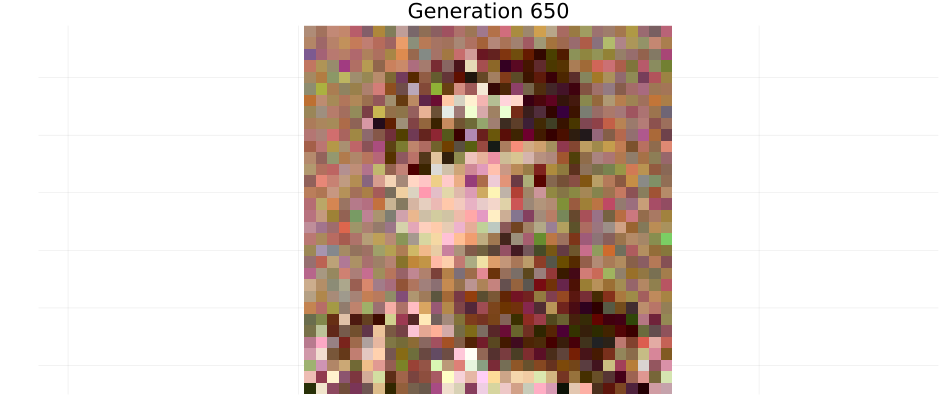

┌ Info: gen=675
│   best_mse = 0.005864232776214287
└   psnr = 22.31788799039005


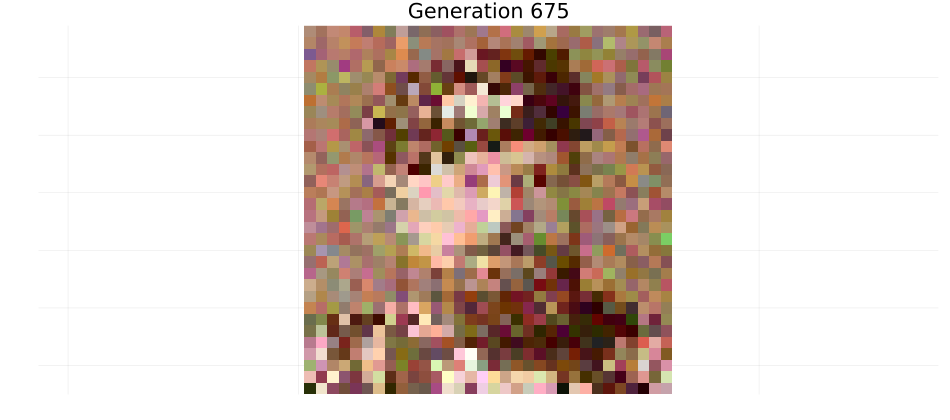

┌ Info: gen=700
│   best_mse = 0.005823085590310095
└   psnr = 22.348468263909965


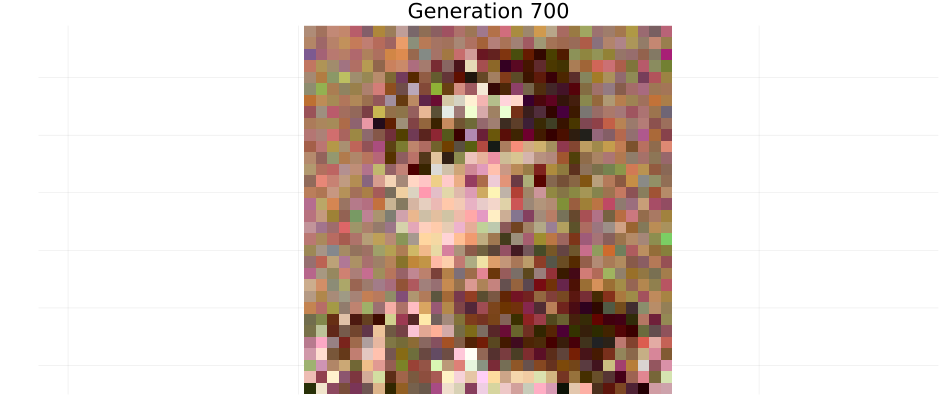

┌ Info: gen=725
│   best_mse = 0.005626986485895591
└   psnr = 22.49724127872135


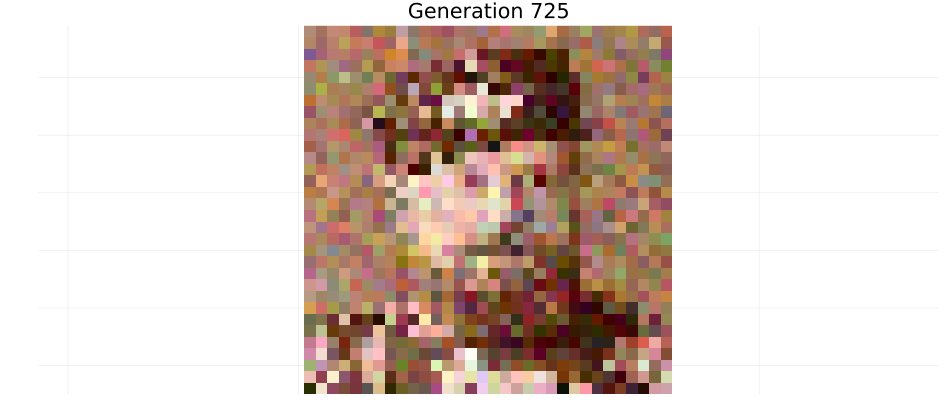

┌ Info: gen=750
│   best_mse = 0.005295101575554804
└   psnr = 22.761257044366037


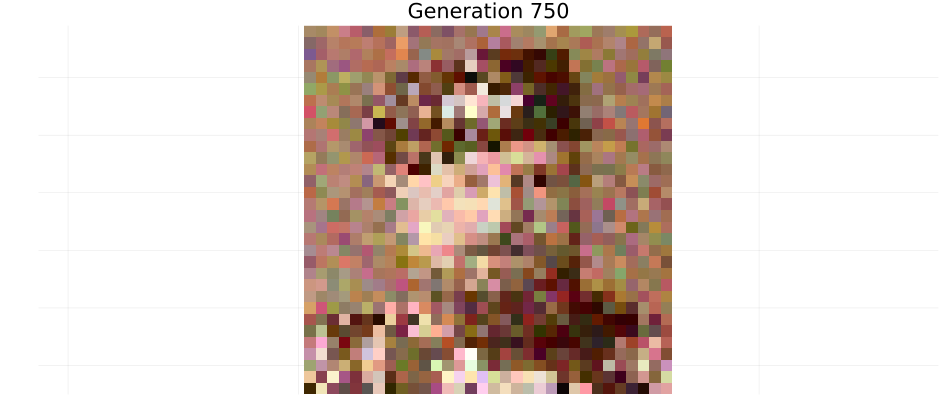

┌ Info: gen=775
│   best_mse = 0.004937315215675087
└   psnr = 23.065091449987737


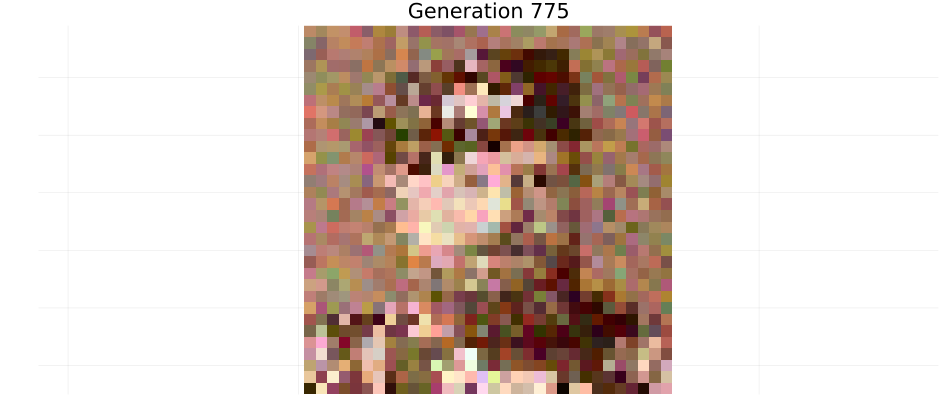

┌ Info: gen=800
│   best_mse = 0.00434685631263941
└   psnr = 23.618247153783337


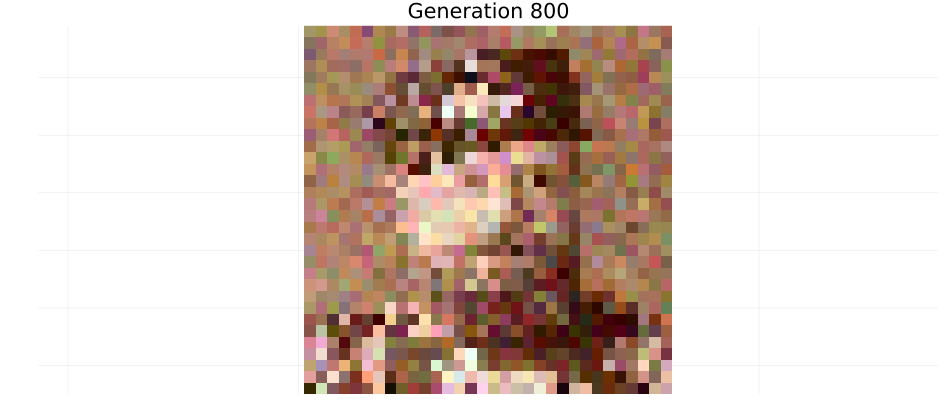

┌ Info: gen=825
│   best_mse = 0.003770812881674905
└   psnr = 24.235650179715485


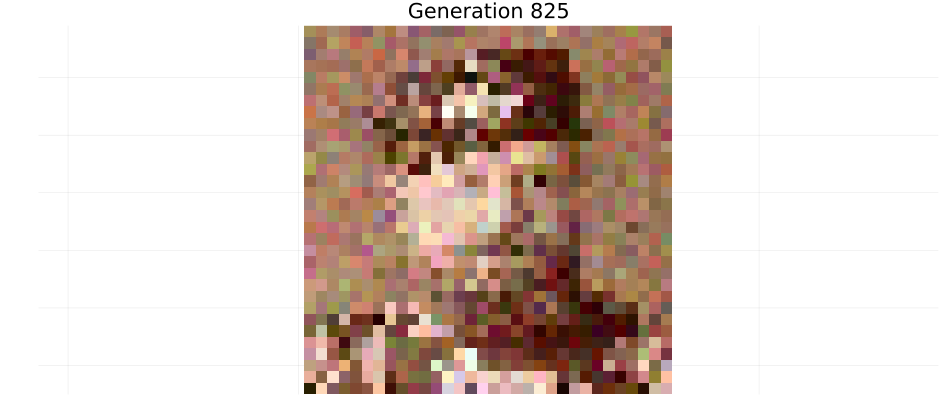

┌ Info: gen=850
│   best_mse = 0.003239914504282876
└   psnr = 24.894664499193357


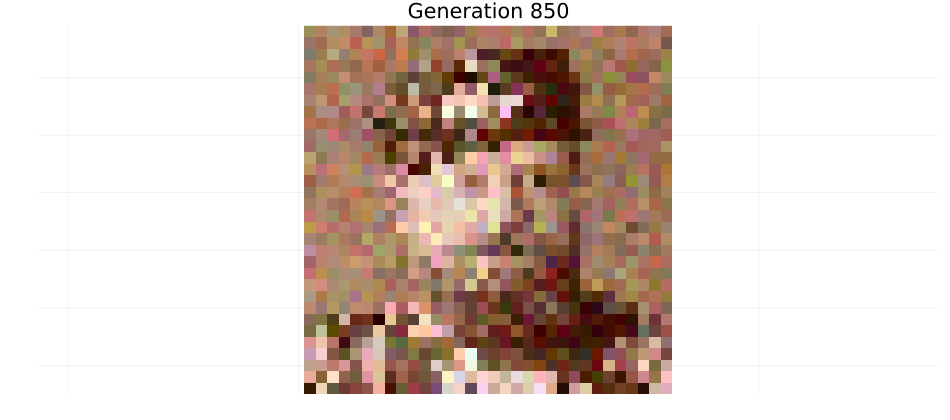

┌ Info: gen=875
│   best_mse = 0.002737142472805634
└   psnr = 25.627025962534027


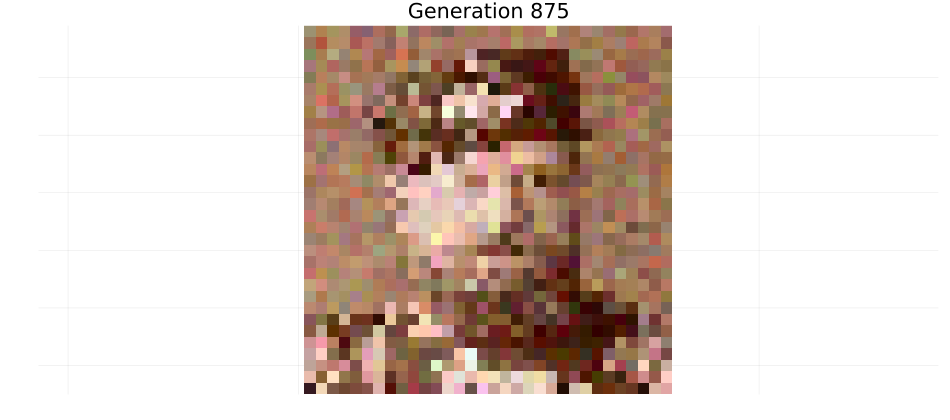

┌ Info: gen=900
│   best_mse = 0.0023066342088201093
└   psnr = 26.370212714028604


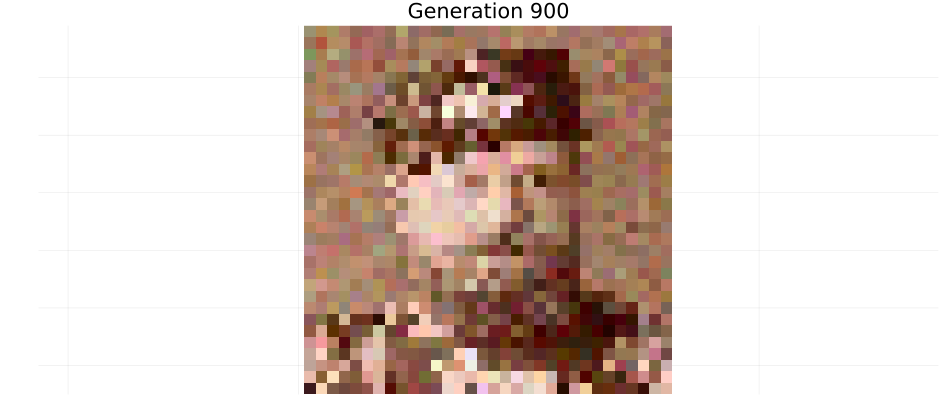

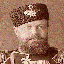

In [12]:
function multiscale_run(target_full::Array{Float32,3}; scales=[32, 64], params=GAParams())
    rng = MersenneTwister(params.seed)
    best = nothing
    hist_all = Float64[]

    for (si, s) in enumerate(scales)
        t = resize_tensor_nn(target_full, s, s)
        p = params
        # на больших масштабах уменьшим sigma, чтобы «шлифовать»
        if si > 1
            p = GAParams(; population_size=params.population_size,
                         generations=Int(round(params.generations * 0.55)),
                         elitism=params.elitism,
                         tournament_k=params.tournament_k,
                         crossover_rate=params.crossover_rate,
                         patch_crossover_prob=params.patch_crossover_prob,
                         mutation_rate_start=max(0.05, params.mutation_rate_start * 0.75),
                         mutation_rate_end=max(0.015, params.mutation_rate_end * 0.75),
                         mutation_sigma_start=max(0.10f0, params.mutation_sigma_start * 0.70f0),
                         mutation_sigma_end=max(0.03f0, params.mutation_sigma_end * 0.70f0),
                         pull_start=params.pull_start,
                         pull_end=params.pull_end,
                         pixel_reset_prob=params.pixel_reset_prob,
                         seed=params.seed)
        end

        if best === nothing
            res = evolve(t; params=p, rng=rng, show_every=25)
            best = res.best
            append!(hist_all, res.best_hist)
        else
            # инициализация: часть популяции — шум вокруг перенесённого best
            best_up = resize_tensor_nn(best, s, s)
            # временно «подмешаем» в init_population: сделаем best кандидатом №1
            function init_with_seed(target, best_seed)
                pop = init_population(target, p, rng)
                pop[1] = copy(best_seed)
                for i in 3:length(pop)
                    pop[i] = clamp.(best_seed .+ 0.10f0 .* randn(rng, Float32, size(best_seed)),
                                    p.clamp_min, p.clamp_max)
                end
                return pop
            end

            pop = init_with_seed(t, best_up)
            fit = [mse(x, t) for x in pop]

            # маленький wrapper evolve без пересоздания init
            function evolve_from_population(pop, fit, target; params=p)
                best_i = argmin(fit)
                best = copy(pop[best_i])
                bestv = fit[best_i]
                best_hist = Float64[]
                mean_hist = Float64[]

                for gen in 1:params.generations
                    elite_idx = partialsortperm(fit, 1:params.elitism)
                    newpop = Vector{Array{Float32,3}}(undef, params.population_size)
                    for (k, ei) in enumerate(elite_idx)
                        newpop[k] = copy(pop[ei])
                    end
                    pos = params.elitism + 1
                    while pos <= params.population_size
                        p1 = pop[tournament_select(fit, params.tournament_k, rng)]
                        p2 = pop[tournament_select(fit, params.tournament_k, rng)]
                        c1, c2 = if rand(rng) < params.crossover_rate
                            if rand(rng) < params.patch_crossover_prob
                                patch_crossover(p1, p2, rng)
                            else
                                two_point_crossover(p1, p2, rng)
                            end
                        else
                            (copy(p1), copy(p2))
                        end

                        t = (gen-1) / max(1, params.generations-1)
                        pm = lerp(params.mutation_rate_start, params.mutation_rate_end, t)
                        sigma = Float32(lerp(params.mutation_sigma_start, params.mutation_sigma_end, t))
                        pull = Float32(lerp(params.pull_start, params.pull_end, t))
                        resetp = lerp(params.pixel_reset_prob, params.pixel_reset_prob * 0.35, t)
                        mutate_guided!(c1, target, pm, sigma, pull, resetp, params, rng)
                        newpop[pos] = c1
                        pos += 1
                        if pos <= params.population_size
                            mutate_guided!(c2, target, pm, sigma, pull, resetp, params, rng)
                            newpop[pos] = c2
                            pos += 1
                        end
                    end
                    pop = newpop
                    fit = [mse(x, target) for x in pop]
                    bi = argmin(fit)
                    bv = fit[bi]
                    if bv < bestv
                        bestv = bv
                        best = copy(pop[bi])
                    end
                    push!(best_hist, bestv)
                    push!(mean_hist, mean(fit))
                end
                return (best=best, best_mse=bestv, best_hist=best_hist, mean_hist=mean_hist)
            end

            res = evolve_from_population(pop, fit, t; params=p)
            best = res.best
            append!(hist_all, res.best_hist)
        end
    end

    return (best=best, best_hist=hist_all)
end

# Настройки под себя
params = GAParams(population_size=56, generations=900, elitism=3, tournament_k=3,
                  mutation_rate_start=0.10, mutation_rate_end=0.02,
                  mutation_sigma_start=0.20f0, mutation_sigma_end=0.04f0,
                  pull_start=0.06f0, pull_end=0.40f0,
                  pixel_reset_prob=0.02,
                  seed=1)

res = multiscale_run(target_t; scales=[32, 64], params=params)
best64 = res.best
best_img64 = from_rgb_float32(best64)
best_img64

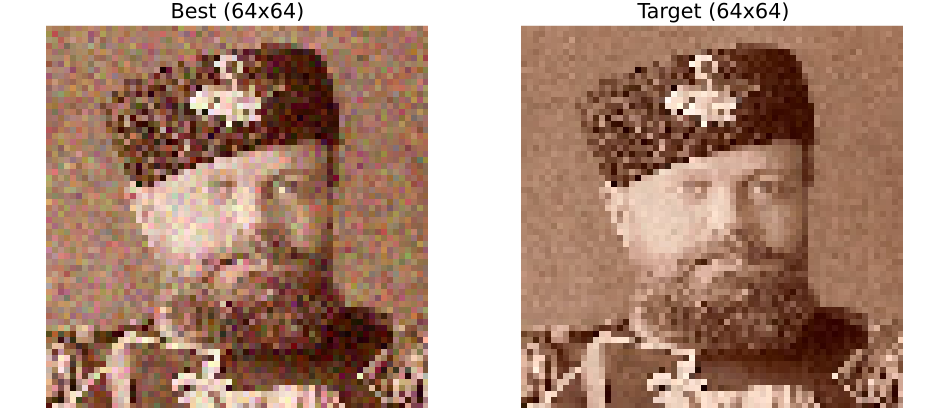

In [13]:
target64 = from_rgb_float32(resize_tensor_nn(target_t, 64, 64))
p1 = plot(best_img64, axis=false, ticks=false, border=:none, title="Best (64x64)")
p2 = plot(target64, axis=false, ticks=false, border=:none, title="Target (64x64)")
plot(p1, p2, layout=(1,2))

┌ Info: gen=1
│   best_mse = 0.1297167226368863
└   psnr = 8.87004032545288
┌ Info: gen=50
│   best_mse = 0.11197487991684556
└   psnr = 9.508793946254428
┌ Info: gen=100
│   best_mse = 0.09450226050232084
└   psnr = 10.245578030045708
┌ Info: gen=150
│   best_mse = 0.08010923534078802
└   psnr = 10.963174136743227
┌ Info: gen=200
│   best_mse = 0.06852552516879094
└   psnr = 11.64147627411463
┌ Info: gen=250
│   best_mse = 0.0584126324878689
└   psnr = 12.334932209270118
┌ Info: gen=300
│   best_mse = 0.049336694838533146
└   psnr = 13.068299481066465
┌ Info: gen=350
│   best_mse = 0.04185294253972194
└   psnr = 13.78274002811951
┌ Info: gen=400
│   best_mse = 0.0353118871602999
└   psnr = 14.520790719751647
┌ Info: gen=450
│   best_mse = 0.029775286096090637
└   psnr = 15.261440569029002
┌ Info: gen=500
│   best_mse = 0.02455770036843714
└   psnr = 16.098123038198615
┌ Info: gen=550
│   best_mse = 0.02010841443668086
└   psnr = 16.96622172493654
┌ Info: gen=600
│   best_mse = 0.01620

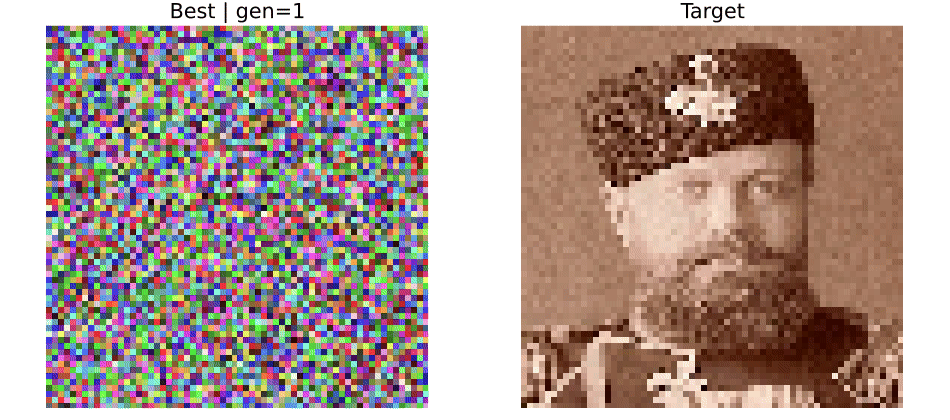

"evolution.gif"

In [24]:

params = GAParams(population_size=56, generations=900, elitism=3, tournament_k=3,
                  mutation_rate_start=0.10, mutation_rate_end=0.02,
                  mutation_sigma_start=0.20f0, mutation_sigma_end=0.04f0,
                  pull_start=0.06f0, pull_end=0.40f0,
                  pixel_reset_prob=0.02,
                  seed=1)

target_small = resize_tensor_nn(target_t, 64, 64)
res = evolve(target_small; params=params, save_every=25, show_every=50)

# Создаём GIF
target_img_small = from_rgb_float32(target_small)
create_gif(res.best_images, target_img_small; filename="evolution.gif", fps=5, step=25, show_target=true)